<a href="https://colab.research.google.com/github/donmatthiuz/DeepLearning/blob/lab6/lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 6

- Mathew Alexander Cordero Aquino 22982
- Pedro Pablo Guzman Mayen  22111




# Investigación Previa

## 1. Funciones recurrentes en PyTorch


###  Forma de entrada esperada
Ambas funciones esperan una entrada con la siguiente forma:

```
(input, (h_0[, c_0]))
```

Donde:
- **input** → tensor de forma `(seq_len, batch_size, input_size)`  
  - `seq_len`: longitud de la secuencia (número de pasos temporales)  
  - `batch_size`: número de ejemplos en el batch  
  - `input_size`: número de características de cada elemento en la secuencia  

Opcionalmente, se pueden pasar los estados iniciales:
- `h_0`: estado oculto inicial, forma `(num_layers * num_directions, batch_size, hidden_size)`
- `c_0`: (solo en LSTM) estado de la celda inicial, misma forma que `h_0`.

---

###  Valores devueltos
Tanto `nn.RNN` como `nn.LSTM` devuelven:

```
output, (h_n, c_n)
```

- **output**: tensor con las salidas para cada paso temporal, de forma  
  `(seq_len, batch_size, num_directions * hidden_size)`
- **h_n**: último estado oculto de cada capa
- **c_n**: (solo en LSTM) último estado de la celda

---

###  Diferencia en número de parámetros
Un **LSTM** tiene más parámetros que una **RNN** simple porque:
- Un RNN solo calcula una única operación de actualización del estado oculto:  
  \( h_t = \tanh(W_{ih}x_t + W_{hh}h_{t-1}) \)
- Un LSTM tiene **cuatro puertas**: entrada, olvido, celda y salida, cada una con sus propios pesos.  
  Esto le permite controlar qué información recordar u olvidar, por lo que necesita aproximadamente **4× más parámetros**.

---

## 2. Capa de Embeddings


###  Propósito en modelos de texto
La capa **Embedding** convierte los índices enteros de las palabras (tokens) en vectores densos de valores reales.  
Sirve como una representación distribuida del vocabulario, donde palabras con significados similares tienen vectores cercanos.

Ejemplo:  
Si el vocabulario es `[“hola”, “mundo”]`, cada palabra se convierte en un vector como:
```
hola → [0.12, -0.45, 0.88]
mundo → [0.03, -0.50, 0.75]
```

---

### Dimensiones de entrada y salida
- **Entrada:** tensor con índices de palabras → tamaño `(batch_size, seq_len)`  
- **Salida:** tensor de embeddings → tamaño `(batch_size, seq_len, embedding_dim)`

Donde:
- `num_embeddings`: tamaño del vocabulario  
- `embedding_dim`: dimensión del vector denso (ej. 100, 300, etc.)

---

###  Vocabulario y token de padding
- Es importante **definir un vocabulario** para asignar a cada palabra un índice único.  
- El **token de padding** (`<PAD>`) se usa para igualar la longitud de las secuencias.  
  PyTorch puede ignorarlo durante el entrenamiento si se define `padding_idx` en `nn.Embedding`.  
  Esto evita que el modelo aprenda pesos inútiles para los valores de relleno.

---

## 3. Dataset IMDB (Large Movie Review Dataset)

### Origen y objetivo
El **Large Movie Review Dataset (IMDB)** fue recopilado por **Andrew L. Maas et al. (2011)** en la Universidad de Stanford.  
Su objetivo principal es **evaluar modelos de análisis de sentimientos** en texto (opiniones positivas o negativas sobre películas).

Referencia:  
📄 Maas et al., *Learning Word Vectors for Sentiment Analysis*, ACL 2011.

---

### Tamaño y distribución
- **Total:** 50,000 reseñas de películas  
  - 25,000 para **entrenamiento**  
  - 25,000 para **prueba**  
- Cada conjunto tiene 50% reseñas **positivas** y 50% **negativas**.  
  No hay traslape entre entrenamiento y prueba.

---

### Tipo de tarea y etiquetas
- **Tipo de tarea:** Clasificación binaria de sentimientos  
- **Etiquetas:**  
  - `0` → reseña negativa  
  - `1` → reseña positiva  



## Referencias

- [`torch.nn.RNN`](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html)  
- [`torch.nn.LSTM`](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
- [`torch.nn.Embedding`](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html)  
- Maas et al., *Learning Word Vectors for Sentiment Analysis*, ACL 2011.


In [1]:
import collections
import time

import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
import transformers


In [2]:
train_data, test_data = datasets.load_dataset("imdb", split=["train", "test"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

### Tokenizacion

In [3]:
transformer_name = "bert-base-uncased"

tokenizer = transformers.AutoTokenizer.from_pretrained(transformer_name)
def tokenize_and_numericalize_example(example, tokenizer):
    ids = tokenizer(example["text"], truncation=True)["input_ids"]
    return {"ids": ids}

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [4]:
train_data = train_data.map(
    tokenize_and_numericalize_example, fn_kwargs={"tokenizer": tokenizer}
)
test_data = test_data.map(
    tokenize_and_numericalize_example, fn_kwargs={"tokenizer": tokenizer}
)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

### Vocabulario



In [5]:
# Obtener vocabulario completo
vocab = tokenizer.get_vocab()
print("Tamaño vocabulario:", len(vocab))

# Buscar ID de un token
token_id = tokenizer.convert_tokens_to_ids("hello")
print("ID de 'hello':", token_id)

# Convertir ID a token
token = tokenizer.convert_ids_to_tokens(7592)
print("Token 7592:", token)


Tamaño vocabulario: 30522
ID de 'hello': 7592
Token 7592: hello


### Conversion a torchs


In [6]:
test_size = 0.25

train_valid_data = train_data.train_test_split(test_size=test_size)
train_data = train_valid_data["train"]
valid_data = train_valid_data["test"]
train_data = train_data.with_format(type="torch", columns=["ids", "label"])
valid_data = valid_data.with_format(type="torch", columns=["ids", "label"])
test_data = test_data.with_format(type="torch", columns=["ids", "label"])

### Creacion de Baches


In [7]:
pad_index = tokenizer.pad_token_id

def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_ids = [i["ids"] for i in batch]
        batch_ids = nn.utils.rnn.pad_sequence(
            batch_ids, padding_value=pad_index, batch_first=True
        )
        batch_label = [i["label"] for i in batch]
        batch_label = torch.stack(batch_label)
        batch = {"ids": batch_ids, "label": batch_label}
        return batch

    return collate_fn
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader
batch_size = 8

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

## Clasificadores

#### RNN

In [8]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: [batch_size, seq_len]
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]
        output, hidden = self.rnn(embedded)
        # output: [batch_size, seq_len, hidden_dim]
        # hidden: [num_layers, batch_size, hidden_dim]
        # Tomamos la última capa oculta de la última secuencia
        last_hidden = hidden[-1]  # [batch_size, hidden_dim]
        out = self.fc(last_hidden)  # [batch_size, output_dim]
        return out


#### LSTM

In [9]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: [batch_size, seq_len]
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]
        output, (hidden, cell) = self.lstm(embedded)
        # hidden: [num_layers, batch_size, hidden_dim]
        last_hidden = hidden[-1]  # [batch_size, hidden_dim]
        out = self.fc(last_hidden)  # [batch_size, output_dim]
        return out

## Entrenamiento

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate(model, data_loader, criterion):
    model.eval()
    epoch_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in data_loader:
            ids = batch["ids"].to(device)
            labels = batch["label"].to(device)
            outputs = model(ids)
            loss = criterion(outputs, labels)
            epoch_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return epoch_loss / total, correct / total

In [11]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs):
    model = model.to(device)
    history = {"train_loss": [], "valid_loss": [], "valid_acc": []}

    start_time_total = time.time()
    for epoch in range(num_epochs):
        model.train()
        start_time_epoch = time.time()
        epoch_loss = 0
        for batch in train_loader:
            ids = batch["ids"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(ids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * labels.size(0)

        epoch_loss /= len(train_loader.dataset)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion)
        epoch_time = time.time() - start_time_epoch

        history["train_loss"].append(epoch_loss)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {epoch_loss:.4f} | "
            f"Valid Loss: {valid_loss:.4f} | "
            f"Valid Acc: {valid_acc:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

    total_time = time.time() - start_time_total
    print(f"Total Training Time: {total_time:.2f}s")
    print(f"Trainable Parameters: {count_parameters(model)}")
    return history


In [12]:
embedding_dim = 100      # Dimensión de los embeddings
hidden_dim = 256
num_layers = 2           # Número de capas RNN/LSTM
output_dim = 2           # Número de clases
num_epochs = 20
learning_rate = 0.001

In [13]:
# Inicializamos modelos
vocab_size = len(tokenizer)  # tamaño del vocabulario
rnn_model = RNNClassifier(vocab_size, embedding_dim, hidden_dim, output_dim, num_layers)
lstm_model = LSTMClassifier(vocab_size, embedding_dim, hidden_dim, output_dim, num_layers)

# Optimizadores
optimizer_rnn = torch.optim.Adam(rnn_model.parameters(), lr=learning_rate)
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate)

# Función de pérdida
criterion = nn.CrossEntropyLoss()

# Entrenar RNN
print("Entrenando RNN...")
history_rnn = train_model(rnn_model, train_data_loader, valid_data_loader, criterion, optimizer_rnn, num_epochs)

# Entrenar LSTM
print("\nEntrenando LSTM...")
history_lstm = train_model(lstm_model, train_data_loader, valid_data_loader, criterion, optimizer_lstm, num_epochs)


Entrenando RNN...
Epoch 1/20 | Train Loss: 0.7130 | Valid Loss: 0.7001 | Valid Acc: 0.4931 | Time: 24.87s
Epoch 2/20 | Train Loss: 0.7136 | Valid Loss: 0.7081 | Valid Acc: 0.4954 | Time: 24.02s
Epoch 3/20 | Train Loss: 0.7184 | Valid Loss: 0.6989 | Valid Acc: 0.5054 | Time: 24.04s
Epoch 4/20 | Train Loss: 0.7135 | Valid Loss: 0.6986 | Valid Acc: 0.4989 | Time: 24.08s
Epoch 5/20 | Train Loss: 0.7159 | Valid Loss: 0.7262 | Valid Acc: 0.5042 | Time: 24.05s
Epoch 6/20 | Train Loss: 0.7195 | Valid Loss: 0.7372 | Valid Acc: 0.4942 | Time: 24.03s
Epoch 7/20 | Train Loss: 0.7169 | Valid Loss: 0.7109 | Valid Acc: 0.5000 | Time: 24.08s
Epoch 8/20 | Train Loss: 0.7162 | Valid Loss: 0.7329 | Valid Acc: 0.4957 | Time: 24.01s
Epoch 9/20 | Train Loss: 0.7161 | Valid Loss: 0.7023 | Valid Acc: 0.5018 | Time: 24.01s
Epoch 10/20 | Train Loss: 0.7174 | Valid Loss: 0.6996 | Valid Acc: 0.5109 | Time: 24.06s
Epoch 11/20 | Train Loss: 0.7154 | Valid Loss: 0.6986 | Valid Acc: 0.4960 | Time: 24.00s
Epoch 12/20 

In [16]:
import matplotlib.pyplot as plt

def plot_training_history(history_rnn, history_lstm):
    epochs = range(1, len(history_rnn["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # --- Gráfica de pérdidas ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_rnn["train_loss"], label="RNN - Train Loss", marker='o')
    plt.plot(epochs, history_rnn["valid_loss"], label="RNN - Valid Loss", marker='o', linestyle='--')
    plt.plot(epochs, history_lstm["train_loss"], label="LSTM - Train Loss", marker='s')
    plt.plot(epochs, history_lstm["valid_loss"], label="LSTM - Valid Loss", marker='s', linestyle='--')
    plt.title("Evolución de la Pérdida")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # --- Gráfica de Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_rnn["valid_acc"], label="RNN - Valid Accuracy", marker='o')
    plt.plot(epochs, history_lstm["valid_acc"], label="LSTM - Valid Accuracy", marker='s')
    plt.title("Evolución de la Precisión (Accuracy)")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


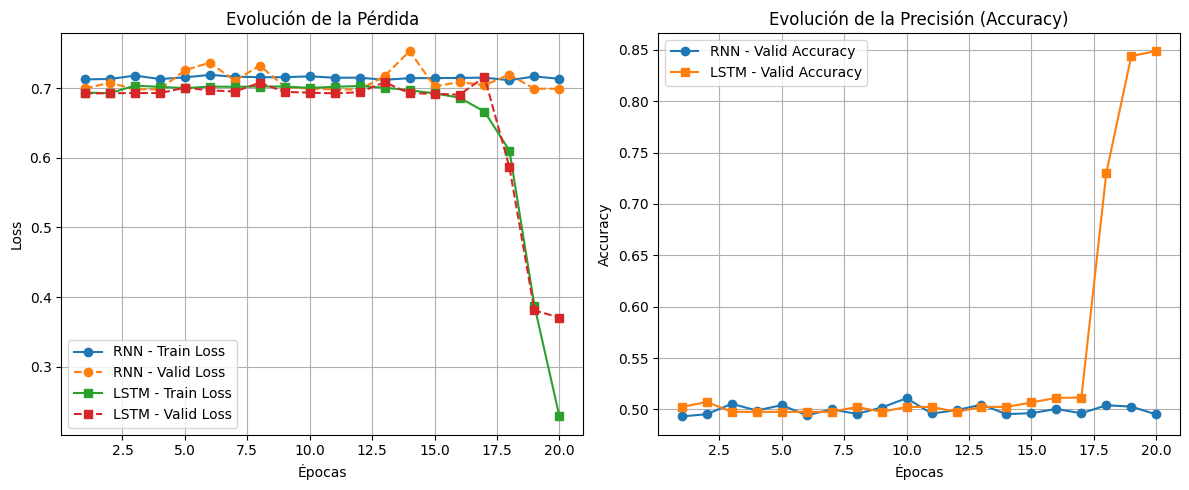

In [17]:
plot_training_history(history_rnn, history_lstm)


Podemos ver que el LSTM tuvo un mejor rendimiento, teniendo mayor acurrancy, esto se puede ver que a la cantidad de 17.5 epocas empieza a mejorar mucho , pero los RNN no mejoro en nada, muy posible debido a que.



## Evaluacion

In [22]:
import time
import pandas as pd

# --- RNN ---
start_rnn = time.time()
history_rnn = train_model(rnn_model, train_data_loader, valid_data_loader, criterion, optimizer_rnn, num_epochs)
total_time_rnn = time.time() - start_rnn

# Evaluar accuracy final
rnn_valid_loss, rnn_valid_acc = evaluate(rnn_model, valid_data_loader, criterion)
rnn_params = count_parameters(rnn_model)

# --- LSTM ---
start_lstm = time.time()
history_lstm = train_model(lstm_model, train_data_loader, valid_data_loader, criterion, optimizer_lstm, num_epochs)
total_time_lstm = time.time() - start_lstm

# Evaluar accuracy final
lstm_valid_loss, lstm_valid_acc = evaluate(lstm_model, valid_data_loader, criterion)
lstm_params = count_parameters(lstm_model)

# Calcular tiempo promedio por época
time_per_epoch_rnn = total_time_rnn / num_epochs
time_per_epoch_lstm = total_time_lstm / num_epochs

# Crear tabla comparativa
comparison = pd.DataFrame({
    "Modelo": ["RNN", "LSTM"],
    "Accuracy final": [rnn_valid_acc, lstm_valid_acc],
    "Tiempo por época (s)": [time_per_epoch_rnn, time_per_epoch_lstm],
    "Tiempo total (s)": [total_time_rnn, total_time_lstm],
    "Número de parámetros": [rnn_params, lstm_params]
})

print(comparison)


Epoch 1/20 | Train Loss: 0.7162 | Valid Loss: 0.7009 | Valid Acc: 0.5000 | Time: 25.33s
Epoch 2/20 | Train Loss: 0.7152 | Valid Loss: 0.7017 | Valid Acc: 0.4994 | Time: 24.79s
Epoch 3/20 | Train Loss: 0.7156 | Valid Loss: 0.7006 | Valid Acc: 0.5058 | Time: 23.90s
Epoch 4/20 | Train Loss: 0.7142 | Valid Loss: 0.6939 | Valid Acc: 0.5021 | Time: 23.93s
Epoch 5/20 | Train Loss: 0.7162 | Valid Loss: 0.7093 | Valid Acc: 0.5029 | Time: 23.89s
Epoch 6/20 | Train Loss: 0.7134 | Valid Loss: 0.7050 | Valid Acc: 0.4949 | Time: 25.23s
Epoch 7/20 | Train Loss: 0.7146 | Valid Loss: 0.7379 | Valid Acc: 0.5123 | Time: 23.99s
Epoch 8/20 | Train Loss: 0.7189 | Valid Loss: 0.7053 | Valid Acc: 0.5149 | Time: 24.01s
Epoch 9/20 | Train Loss: 0.7133 | Valid Loss: 0.7081 | Valid Acc: 0.4989 | Time: 24.06s
Epoch 10/20 | Train Loss: 0.7162 | Valid Loss: 0.7322 | Valid Acc: 0.5064 | Time: 24.00s
Epoch 11/20 | Train Loss: 0.7152 | Valid Loss: 0.7029 | Valid Acc: 0.4970 | Time: 24.92s
Epoch 12/20 | Train Loss: 0.71

## Discusion




- ¿Qué modelo obtuvo mayor calidad en los resultados?

- ¿Qué diferencias se observaron en tiempos de entrenamiento?
- ¿Cómo influye el número de parámetros en el desempeño?

- ¿Qué ventajas y desventajas tiene cada arquitectura en este tipo de tarea?